In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
# Load cleaned dataset
file_path = "..\\Data\\processed\\VNSGU_SEM4_All_Student_Results_Cleaned.csv"
df = pd.read_csv(file_path)

# Select only performance-related features
features = [
    "JAVA_Total",
    "NET_Total",
    "MAD_Total",
    "IOT_Total",
    "OSS_Total",
    "CC_Total",
    "BMP_Total"
]

X = df[features]

# Check basic info
print("Shape of feature matrix (X):", X.shape)

print("\nFirst 5 rows of X:")
print(X.head())


Shape of feature matrix (X): (9157, 7)

First 5 rows of X:
   JAVA_Total  NET_Total  MAD_Total  IOT_Total  OSS_Total  CC_Total  BMP_Total
0          41         51         44          0         46        23         27
1          45         57         57         46         44        29         28
2          50         55         57         65         46        27         33
3          39         53         50         52         47        26         30
4          47         52         59         54         44        42         27


In [3]:
# Check for missing values
print("\nMissing values in each column:")
print(X.isnull().sum())



Missing values in each column:
JAVA_Total    0
NET_Total     0
MAD_Total     0
IOT_Total     0
OSS_Total     0
CC_Total      0
BMP_Total     0
dtype: int64


In [4]:
# Create scaler
scaler = StandardScaler()

# Scale the feature matrix
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (for readability)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Check result
print("First 5 rows of scaled data:")
print(X_scaled_df.head())


First 5 rows of scaled data:
   JAVA_Total  NET_Total  MAD_Total  IOT_Total  OSS_Total  CC_Total  BMP_Total
0   -1.814071  -1.184215  -2.010540  -3.846864   1.228551 -2.112440  -0.815297
1   -1.510223  -0.718053  -0.941696  -0.998809   0.881874 -1.305335  -0.662399
2   -1.130413  -0.873440  -0.941696   0.177561   1.228551 -1.574370   0.102087
3   -1.965995  -1.028828  -1.517227  -0.627324   1.401889 -1.708888  -0.356605
4   -1.358299  -1.106521  -0.777258  -0.503495   0.881874  0.443392  -0.815297


In [5]:
print("\nMean of scaled features:")
print(X_scaled_df.mean())

print("\nStandard deviation of scaled features:")
print(X_scaled_df.std())



Mean of scaled features:
JAVA_Total    3.786664e-16
NET_Total    -3.429725e-16
MAD_Total    -4.314314e-16
IOT_Total     9.932234e-17
OSS_Total    -4.221200e-16
CC_Total     -1.179453e-16
BMP_Total     1.241529e-17
dtype: float64

Standard deviation of scaled features:
JAVA_Total    1.000055
NET_Total     1.000055
MAD_Total     1.000055
IOT_Total     1.000055
OSS_Total     1.000055
CC_Total      1.000055
BMP_Total     1.000055
dtype: float64


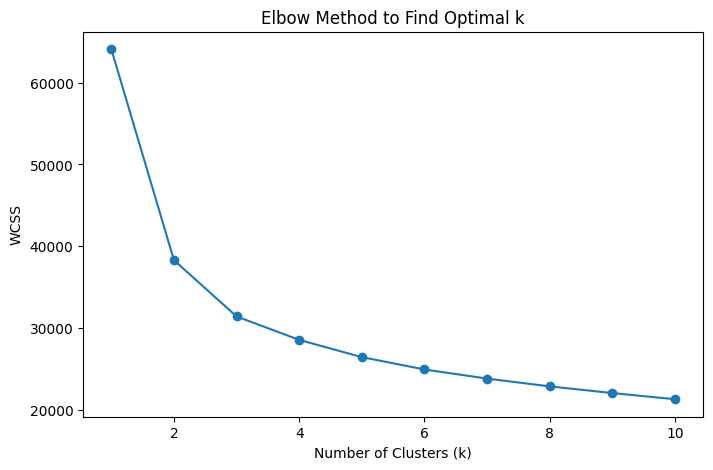

In [6]:
wcss = []  # store WCSS values

# Try k from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method to Find Optimal k")
plt.show()


In [7]:
# Create KMeans model with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit model and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df["Cluster"] = clusters

# Check first few rows
df[[
    "JAVA_Total",
    "NET_Total",
    "MAD_Total",
    "IOT_Total",
    "OSS_Total",
    "CC_Total",
    "BMP_Total",
    "Cluster"
]].head()

,JAVA_Total,NET_Total,MAD_Total,IOT_Total,OSS_Total,CC_Total,BMP_Total,Cluster
0,41,51,44,0,46,23,27,2
1,45,57,57,46,44,29,28,2
2,50,55,57,65,46,27,33,0
3,39,53,50,52,47,26,30,2
4,47,52,59,54,44,42,27,0


In [8]:
# Number of students in each cluster
print(df["Cluster"].value_counts())


Cluster
0    4055
1    2973
2    2129
Name: count, dtype: int64


In [9]:
# Select only feature columns + Cluster
features = [
    "JAVA_Total",
    "NET_Total",
    "MAD_Total",
    "IOT_Total",
    "OSS_Total",
    "CC_Total",
    "BMP_Total"
]

# Calculate cluster-wise mean
cluster_summary = df.groupby("Cluster")[features].mean()

print(cluster_summary)

         JAVA_Total  NET_Total  MAD_Total  IOT_Total  OSS_Total   CC_Total  \
Cluster                                                                      
0         63.379778  64.511221  67.219482  60.977559  38.844636  38.966461   
1         77.881601  79.586276  80.614194  75.776320  43.096535  43.297006   
2         49.587130  50.904650  53.822452  45.278065  33.198685  31.789573   

         BMP_Total  
Cluster             
0        31.719605  
1        37.294316  
2        26.570221  


In [10]:
# Map cluster numbers to performance labels
performance_map = {
    0: "High Performer",
    1: "Average Performer",
    2: "Needs Improvement"
}

df["Performance_Level"] = df["Cluster"].map(performance_map)

df[["Cluster", "Performance_Level"]].head()


,Cluster,Performance_Level
0,2,Needs Improvement
1,2,Needs Improvement
2,0,High Performer
3,2,Needs Improvement
4,0,High Performer


In [11]:
# Reduce data to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"]
pca_df["Performance_Level"] = df["Performance_Level"]

pca_df.head()


,PC1,PC2,Cluster,Performance_Level
0,4.035878,-0.580269,2,Needs Improvement
1,2.021383,-0.652413,2,Needs Improvement
2,1.204706,-1.555886,0,High Performer
3,2.302580,-1.309292,2,Needs Improvement
4,1.416354,0.690140,0,High Performer


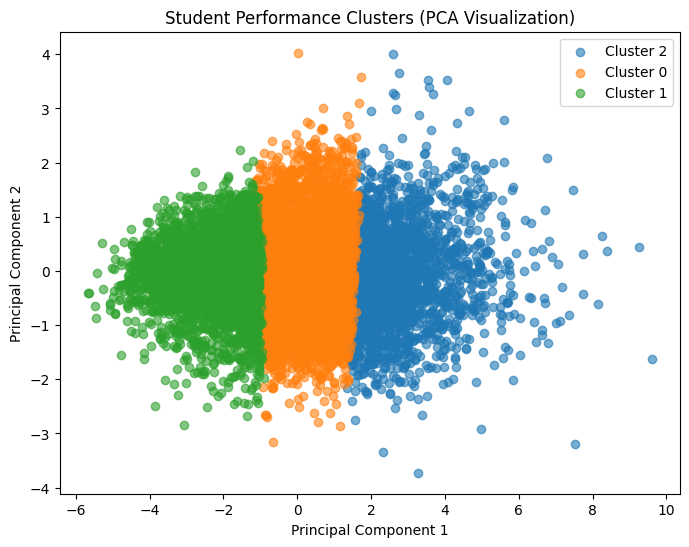

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for cluster in pca_df["Cluster"].unique():
    subset = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Student Performance Clusters (PCA Visualization)")
plt.legend()
plt.show()


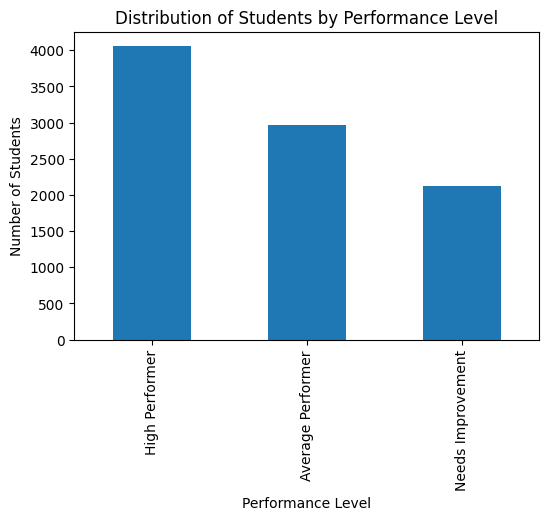

In [13]:
df["Performance_Level"].value_counts().plot(kind="bar", figsize=(6,4))
plt.xlabel("Performance Level")
plt.ylabel("Number of Students")
plt.title("Distribution of Students by Performance Level")
plt.show()


In [14]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df["Cluster"])
print("Silhouette Score:", score)


Silhouette Score: 0.23284802811648014


In [ ]:
import joblib

joblib.dump(kmeans, "..\\models\\kmeans_model.pkl")
joblib.dump(scaler, "..\\models\\scaler.pkl")
joblib.dump(pca, "..\\models\\pca_model.pkl")


['D:\\VNSGU_PDA2\\Data-Analytics-using-Python-Minor-Project\\models\\pca_model.pkl']

In [ ]:
df.to_excel(
    "..\\outputs\\final_student_clustered_data.xlsx",
    index=False
)
cluster_summary.to_csv(
    "..\\outputs\\cluster_summary.csv"
)

